# Análisis del Dataset SIVIGILA - VIH/SIDA

Este notebook explora el dataset de vigilancia epidemiológica para encontrar patrones sobre los casos registrados según su ubicación en la ciudad.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('../data/sivigila_vih(in).csv', encoding='latin1', low_memory=False)
df.head()

,cod_eve,fec_not,semana,aÃ±o,cod_pre,cod_sub,edad_,uni_med_,nacionali_,nombre_nacionalidad,...,clasificaciÃ³n_final,codigo_barrio,codigo_comuna,nombre_barrio,nombre_comuna,grupo_edad_quinque,grupo_edad_ciclo,periodo_epid,mes_caso,ID
0,850,29/01/2022,4,2022,500105568,13,27,1,170.0,COLOMBIA,...,3,304,3,Santa InÃ©s,03 Manrique,25-29,18-28,1,1,0xAF726EDB4B21FF3D2FACB4E62EB6C302DAF4A56E8685...
1,850,25/02/2021,8,2021,500102175,1,26,1,170.0,COLOMBIA,...,3,9999,99,Sin InformaciÃ³n,Sin InformaciÃ³n,25-29,18-28,2,2,0xAF72E09C1FF26C865EA1E183B32ED240C9CDF1002C14...
2,850,11/2/2023,6,2023,500102178,57,33,1,170.0,COLOMBIA,...,3,207,2,Villa del Socorro,02 Santa Cruz,30-34,29-59,2,2,0xAF73235848357C53380ED8EF0CDAE1A1DEA7A72833A7...
3,850,9/7/2020,28,2020,500116163,1,59,1,170.0,COLOMBIA,...,3,9999,99,Sin InformaciÃ³n,Sin InformaciÃ³n,55-59,29-59,7,7,0xAF733665CB87B3B1FE02F156C339F58613E06AA81A22...
4,850,2/9/2014,36,2014,500102144,1,55,1,NaN,NaN,...,3,905,9,Alejandro EchavarrÃ­a,09 Buenos Aires,55-59,29-59,9,9,0xAF748987E0EC472FDF92CAB895AD0401E3FB7C92EF5D...


## Limpieza de datos
Filtramos las columnas de interés y revisamos valores nulos.

In [25]:
# Seleccionar columnas relevantes para el análisis
df_clean = df[['fec_not', 'edad_', 'sexo_', 'nombre_comuna', 'Grupo_Edad', 'nom_eve', 'tip_ss_']].copy()

# Ver nulos
print(df_clean.isnull().sum())

# Eliminar nulos en sexo y edad
df_clean = df_clean.dropna(subset=['sexo_', 'edad_', 'nombre_comuna'])

fec_not          0
edad_            0
sexo_            0
nombre_comuna    0
Grupo_Edad       3
nom_eve          0
tip_ss_          0
dtype: int64


## Análisis exploratorio y Visualización

In [26]:
#Casos categorizados por barrio, edad y sexo, categorizados por grupos de edad, donde muestra el barrio el grupo de la edad
#el sexo y la cantidad de datos en conjunto de esta categoría
bins = [0, 14, 24, 34, 44, 54, 64, 100]

labels = ["0-14", "15-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["Grupo_Edad"] = pd.cut(df["edad_"], bins=bins, labels=labels)

analisis = df.groupby(
    ["nombre_comuna", "Grupo_Edad", "sexo_"],
    observed=True
).size().reset_index(name="Casos")

analisis.head(100)


,nombre_comuna,Grupo_Edad,sexo_,Casos
0,01 Popular,0-14,M,5
1,01 Popular,15-24,F,35
2,01 Popular,15-24,M,146
3,01 Popular,25-34,F,47
4,01 Popular,25-34,M,193
...,...,...,...,...
95,08 Villa Hermosa,25-34,F,51
96,08 Villa Hermosa,25-34,M,273
97,08 Villa Hermosa,35-44,F,31
98,08 Villa Hermosa,35-44,M,115


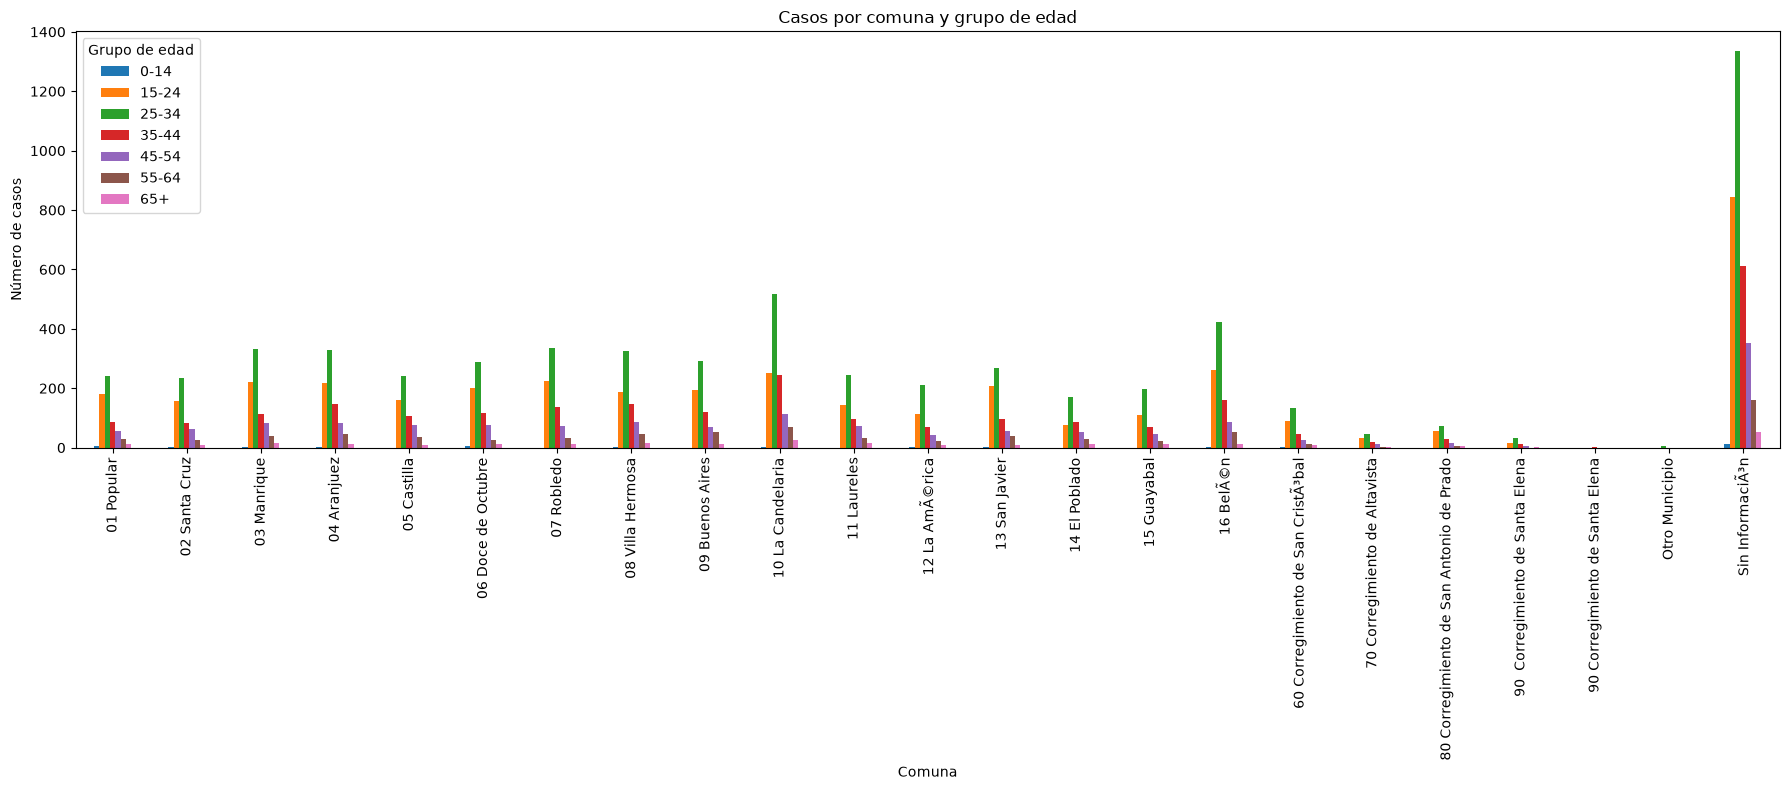

In [28]:
datos_barrio_edad = df_clean.groupby(
    ['nombre_comuna', 'Grupo_Edad'],
    observed=True
).size().reset_index(name='casos')

tabla_barrio_edad = datos_barrio_edad.pivot(
    index='nombre_comuna',
    columns='Grupo_Edad',
    values='casos'
).fillna(0)

tabla_barrio_edad.plot(
    kind='bar',
    figsize=(18, 8)
)

plt.title('Casos por comuna y grupo de edad')
plt.xlabel('Comuna')
plt.ylabel('Número de casos')
plt.xticks(rotation=90)
plt.legend(title='Grupo de edad')
plt.tight_layout()
plt.show()


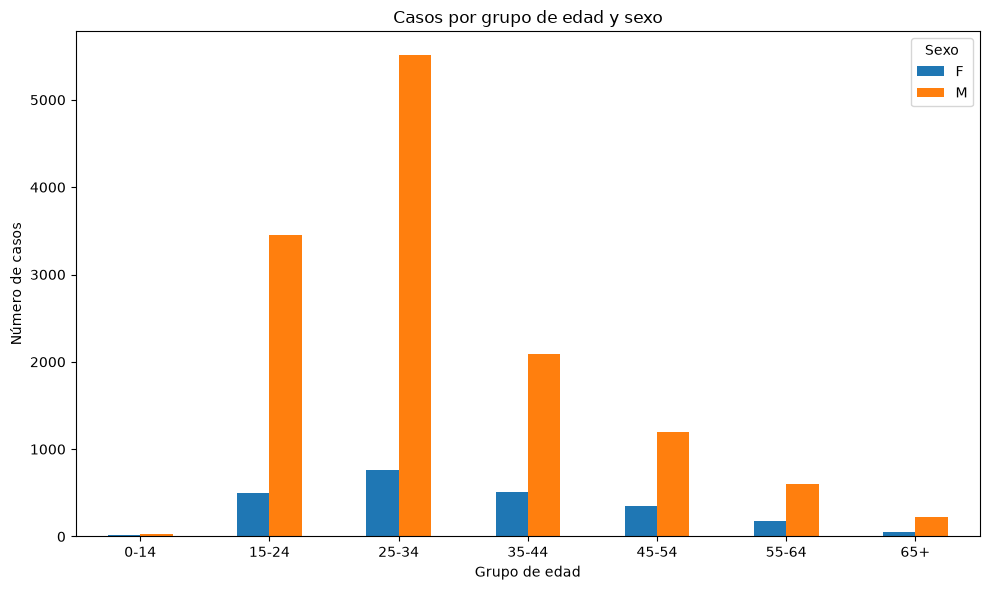

In [29]:
datos_edad_sexo = df_clean.groupby(
    ['Grupo_Edad', 'sexo_']
).size().reset_index(name='casos')

tabla_edad_sexo = datos_edad_sexo.pivot(
    index='Grupo_Edad',
    columns='sexo_',
    values='casos'
).fillna(0)

tabla_edad_sexo.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Casos por grupo de edad y sexo')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de casos')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

## Consluciones

1.Podemos concluir de la información de la gráfica edad vs comuna que la comuna 10 y el grupo de la edad de entre 25 a 34 años es la población más afectada por el SIDA o VIH

2. De la gráfica de edad vs Sexo podemos concluir que la población más afectada es la masculina entre las edades entre los 25 a los 34 años